# XIC (Extracted Ion Chromatogram) 추출

**XIC**는 특정 m/z 값의 이온만 시간축으로 추출한 크로마토그램입니다. TIC와의 핵심 차이를 이해하는 것이 중요합니다:

| | TIC | XIC |
|---|---|---|
| **추출 대상** | 모든 이온의 합 | 특정 m/z 하나 |
| **용도** | 전체 윤곽 파악 | 개별 화합물 선택적 검출 |
| **노이즈** | 모든 배경 포함 | 해당 m/z 근처만 |

EchoMS 데이터에서 XIC를 추출하면:
- 각 echo drop마다 해당 화합물의 **spike**가 나타남 (시료에 존재하는 경우)
- spike가 없으면 그 화합물은 시료에 없는 것 -- XIC의 **선택성(selectivity)**
- **tolerance (ppm)**은 m/z 추출 윈도우의 폭을 결정하는 핵심 파라미터

이 노트북에서는:
1. 엑셀 스킴에서 화합물 목록 로드
2. XIC 추출 함수 정의 및 7종 화합물 추출
3. 개별/overlay 시각화
4. 실제 화합물 vs 없는 화합물 비교로 선택성 검증

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import integrate
import pyopenms as oms
import openpyxl, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

### 데이터 로드 및 함수 복원

mzML 파일을 로드하고, TIC/XIC 추출 함수를 정의하며, 화합물 목록을 엑셀에서 가져옵니다. 이전 노트북의 bootstrap 셀과 동일한 역할입니다.

In [2]:
# === 데이터 로드 ===
DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment()
    oms.MzMLFile().load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)} ({exp.getNrSpectra()} spectra)')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

def extract_tic(exp, ms_level=1):
    """TIC 추출"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합"""
    rt_list, int_list = [], []
    tol = target_mz * tolerance_ppm * 1e-6
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, ints = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)
    return np.array(rt_list), np.array(int_list)

# 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and row[1]:
        compounds.append({'name': str(row[2] or row[1]), 'full_name': str(row[1]), 'mz': None})

# XIC 추출
target_compounds = {
    'TNT': {'mz': 226.009, 'adduct': '[M-H]-'},
    'RDX': {'mz': 281.048, 'adduct': '[M+CH3COO]-'},
    'HMX': {'mz': 355.0592, 'adduct': '[M+CH3COO]-'},
    '2,4-DNT': {'mz': 181.0124, 'adduct': '[M-H]-'},
    'Tetryl': {'mz': 241.0204, 'adduct': '[M-NO2]-'},
    '4-Am-DNT': {'mz': 196.0358, 'adduct': '[M-H]-'},
    '2,6-DNT': {'mz': 182.018, 'adduct': '[M]-'},
}

xic_data = {}
for name, info in target_compounds.items():
    rt, intensity = extract_xic(exp_tof, info['mz'])
    xic_data[name] = {'rt': rt, 'intensity': intensity, 'mz': info['mz']}

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f'검출된 화합물: {len(detected)}/{len(target_compounds)}')

Loaded: 20260330_TOFMS.mzML (495 spectra)
Detected compounds: 7/7



## 화합물 스킴 로드

**화합물 스킴(compound scheme)**은 분석 대상 화합물의 이름, m/z, adduct type 목록입니다. XIC 추출의 기초가 되는 정보이므로 정확해야 합니다.

엑셀 파일에는 두 개의 시트로 정리하였습니다:
- **STD list**: EPA 8330 폭발물 표준 혼합물 15종의 화합물 명칭과 약어
- **MRM**: 각 화합물의 precursor m/z (Q1), product m/z (Q3), adduct type, collision energy (CE)
- MRM transition 정보는 이 노트북에서는 참조용이지만, 나중에 MS/MS 분석 노트북에서 핵심적으로 사용됩니다

In [3]:
# 엑셀에서 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)

# STD list 시트에서 화합물 정보 추출
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and isinstance(row[0], (int, float)):
        compounds.append({
            'no': int(row[0]),
            'name': row[1],
            'abbrev': row[2],
            'source_type': row[6] if row[6] else ''
        })

# MRM 시트에서 transition 정보 추출
ws_mrm = wb['MRM']
transitions = []
for row in ws_mrm.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[1] and isinstance(row[1], (int, float)):
        transitions.append({
            'precursor_mz': row[1],   # Q1
            'product_mz': row[2],     # Q3
            'acc': row[3],            # accumulation time
            'name': row[4],           # ID
            'adduct': row[5],         # adduct type
            'CE': row[8],             # collision energy
        })

df_compounds = pd.DataFrame(compounds)
df_transitions = pd.DataFrame(transitions)

print('=== 화합물 목록 ===')
display(df_compounds[['no', 'name', 'abbrev']]) if 'google.colab' in str(get_ipython()) else print(df_compounds[['no', 'name', 'abbrev']].to_string())
print(f'\n=== MRM Transitions ({len(df_transitions)}개) ===')
display(df_transitions[['name', 'precursor_mz', 'product_mz', 'adduct', 'CE']]) if 'google.colab' in str(get_ipython()) else print(df_transitions[['name', 'precursor_mz', 'product_mz', 'adduct', 'CE']].to_string())

=== Compound List ===
(See table in Excel)

=== MRM Transitions (14) ===
          name  precursor_mz  product_mz     adduct  CE
0    2,4-DNT 1      181.0124     45.9930       M-H- -42
1    2,4-DNT 2      181.0124    135.0180       M-H- -25
2    2,6-DNT 1      182.0180     45.9930         M- -26
3    2,6-DNT 2      182.0180    152.0240         M- -12
4        HMX 1      355.0592     45.9930  M+CH3COO- -58
5        HMX 2      355.0592     59.0138  M+CH3COO- -35
6     Tetryl 1      241.0204    213.0007     M-NO2- -15
7     Tetryl 2      241.0204    195.9970     M-NO2- -25
8        TNT 1      226.0090     45.9930       M-H- -42
9        TNT 2      226.0090    196.0000       M-H- -18
10       TNT 3      226.0090     50.0026       M-H- -35
11       RDX 1      281.0480     45.9930  M+CH3COO- -26
12       RDX 2      281.0480     59.0130  M+CH3COO- -36
13  4-Am-DNT 1      196.0358     45.9930       M-H- -58



## XIC 추출 함수 정의 및 실행

`extract_xic()` 함수는 각 스캔에서 `target_mz +/- tolerance` 범위의 intensity만 합산하여 특정 화합물의 시간-강도 프로파일을 생성합니다.

**tolerance_ppm**은 XIC 추출에서 가장 중요한 파라미터입니다:
- **20 ppm** = m/z 226에서 +/-0.0045 Da 윈도우
- 너무 **좁으면** (예: 5 ppm) -> mass accuracy 한계로 신호 손실 가능
- 너무 **넓으면** (예: 100 ppm) -> 근처 간섭 이온이 포함되어 위양성 발생
- **ppm (parts per million)** 단위를 사용하는 이유: m/z가 클수록 동일 ppm에서도 Da 단위 오차가 커지므로, 상대 오차가 더 적절합니다

7종 대상 화합물에 대해 각각 XIC를 추출하고 검출 여부를 확인합니다.

In [4]:
def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합
    
    Parameters
    ----------
    exp : MSExperiment
    target_mz : float — 추출할 m/z 값
    tolerance_ppm : float — 허용 오차 (ppm)
    ms_level : int — MS level (1=MS1, 2=MS/MS)
    
    Returns
    -------
    rt_arr, intensity_arr : 시간(분)과 강도 배열
    """
    tol_da = target_mz * tolerance_ppm * 1e-6
    mz_low = target_mz - tol_da
    mz_high = target_mz + tol_da
    
    rt_list, int_list = [], []
    for spec in exp:
        if spec.getMSLevel() != ms_level:
            continue
        rt_list.append(spec.getRT() / 60.0)
        mz, intensity = spec.get_peaks()
        mask = (mz >= mz_low) & (mz <= mz_high)
        int_list.append(np.sum(intensity[mask]))
    
    return np.array(rt_list), np.array(int_list)

# 대표 화합물 XIC 추출: TNT (m/z 226.009, [M-H]-)
target_compounds = {
    'TNT':      {'mz': 226.009, 'adduct': '[M-H]-'},
    'RDX':      {'mz': 281.048, 'adduct': '[M+CH3COO]-'},
    'HMX':      {'mz': 355.0592, 'adduct': '[M+CH3COO]-'},
    '2,4-DNT':  {'mz': 181.0124, 'adduct': '[M-H]-'},
    'Tetryl':   {'mz': 241.0204, 'adduct': '[M-NO2]-'},
    '4-Am-DNT': {'mz': 196.0358, 'adduct': '[M-H]-'},
    '2,6-DNT':  {'mz': 182.018, 'adduct': '[M]-'},
}

print('XIC 추출 중...')
xic_data = {}
for name, info in target_compounds.items():
    rt, intensity = extract_xic(exp_tof, info['mz'], tolerance_ppm=20)
    xic_data[name] = {'rt': rt, 'intensity': intensity, 'mz': info['mz']}
    max_int = intensity.max()
    if max_int > 0:
        print(f'  {name:10s} m/z={info["mz"]:.3f}  max={max_int:.2e}  at {rt[np.argmax(intensity)]:.2f} min')
    else:
        print(f'  {name:10s} m/z={info["mz"]:.3f}  — 검출 안 됨')

XIC extraction...
  TNT        m/z=226.0090  max=1.22e+04  at 1.44 min
  RDX        m/z=281.0480  max=1.09e+03  at 1.44 min
  HMX        m/z=355.0592  max=2.95e+04  at 1.44 min
  2,4-DNT    m/z=181.0124  max=3.09e+04  at 1.44 min
  Tetryl     m/z=241.0204  max=4.13e+03  at 1.44 min
  4-Am-DNT   m/z=196.0358  max=1.04e+05  at 1.44 min
  2,6-DNT    m/z=182.0180  max=3.98e+03  at 1.44 min


## XIC 개별 시각화 -- 검출된 화합물

검출된 화합물(intensity > 0)만 필터링하여 개별 XIC 플롯을 그립니다. 각 그래프에서 확인할 포인트:

- **spike = echo drop**: 각 뾰족한 피크가 하나의 시료 드롭에 해당합니다. spike 수 = drop 수
- **spike 높이**: 해당 drop에서의 화합물 검출 강도. 높을수록 많은 양이 검출된 것
- **피크 모양**: 좌우 대칭이고 좁은 피크가 이상적. 넓거나 비대칭이면 ion suppression이나 carry-over 가능성
- **기저선**: spike 사이 구간이 0에 가까워야 정상. 높으면 background 오염 의심

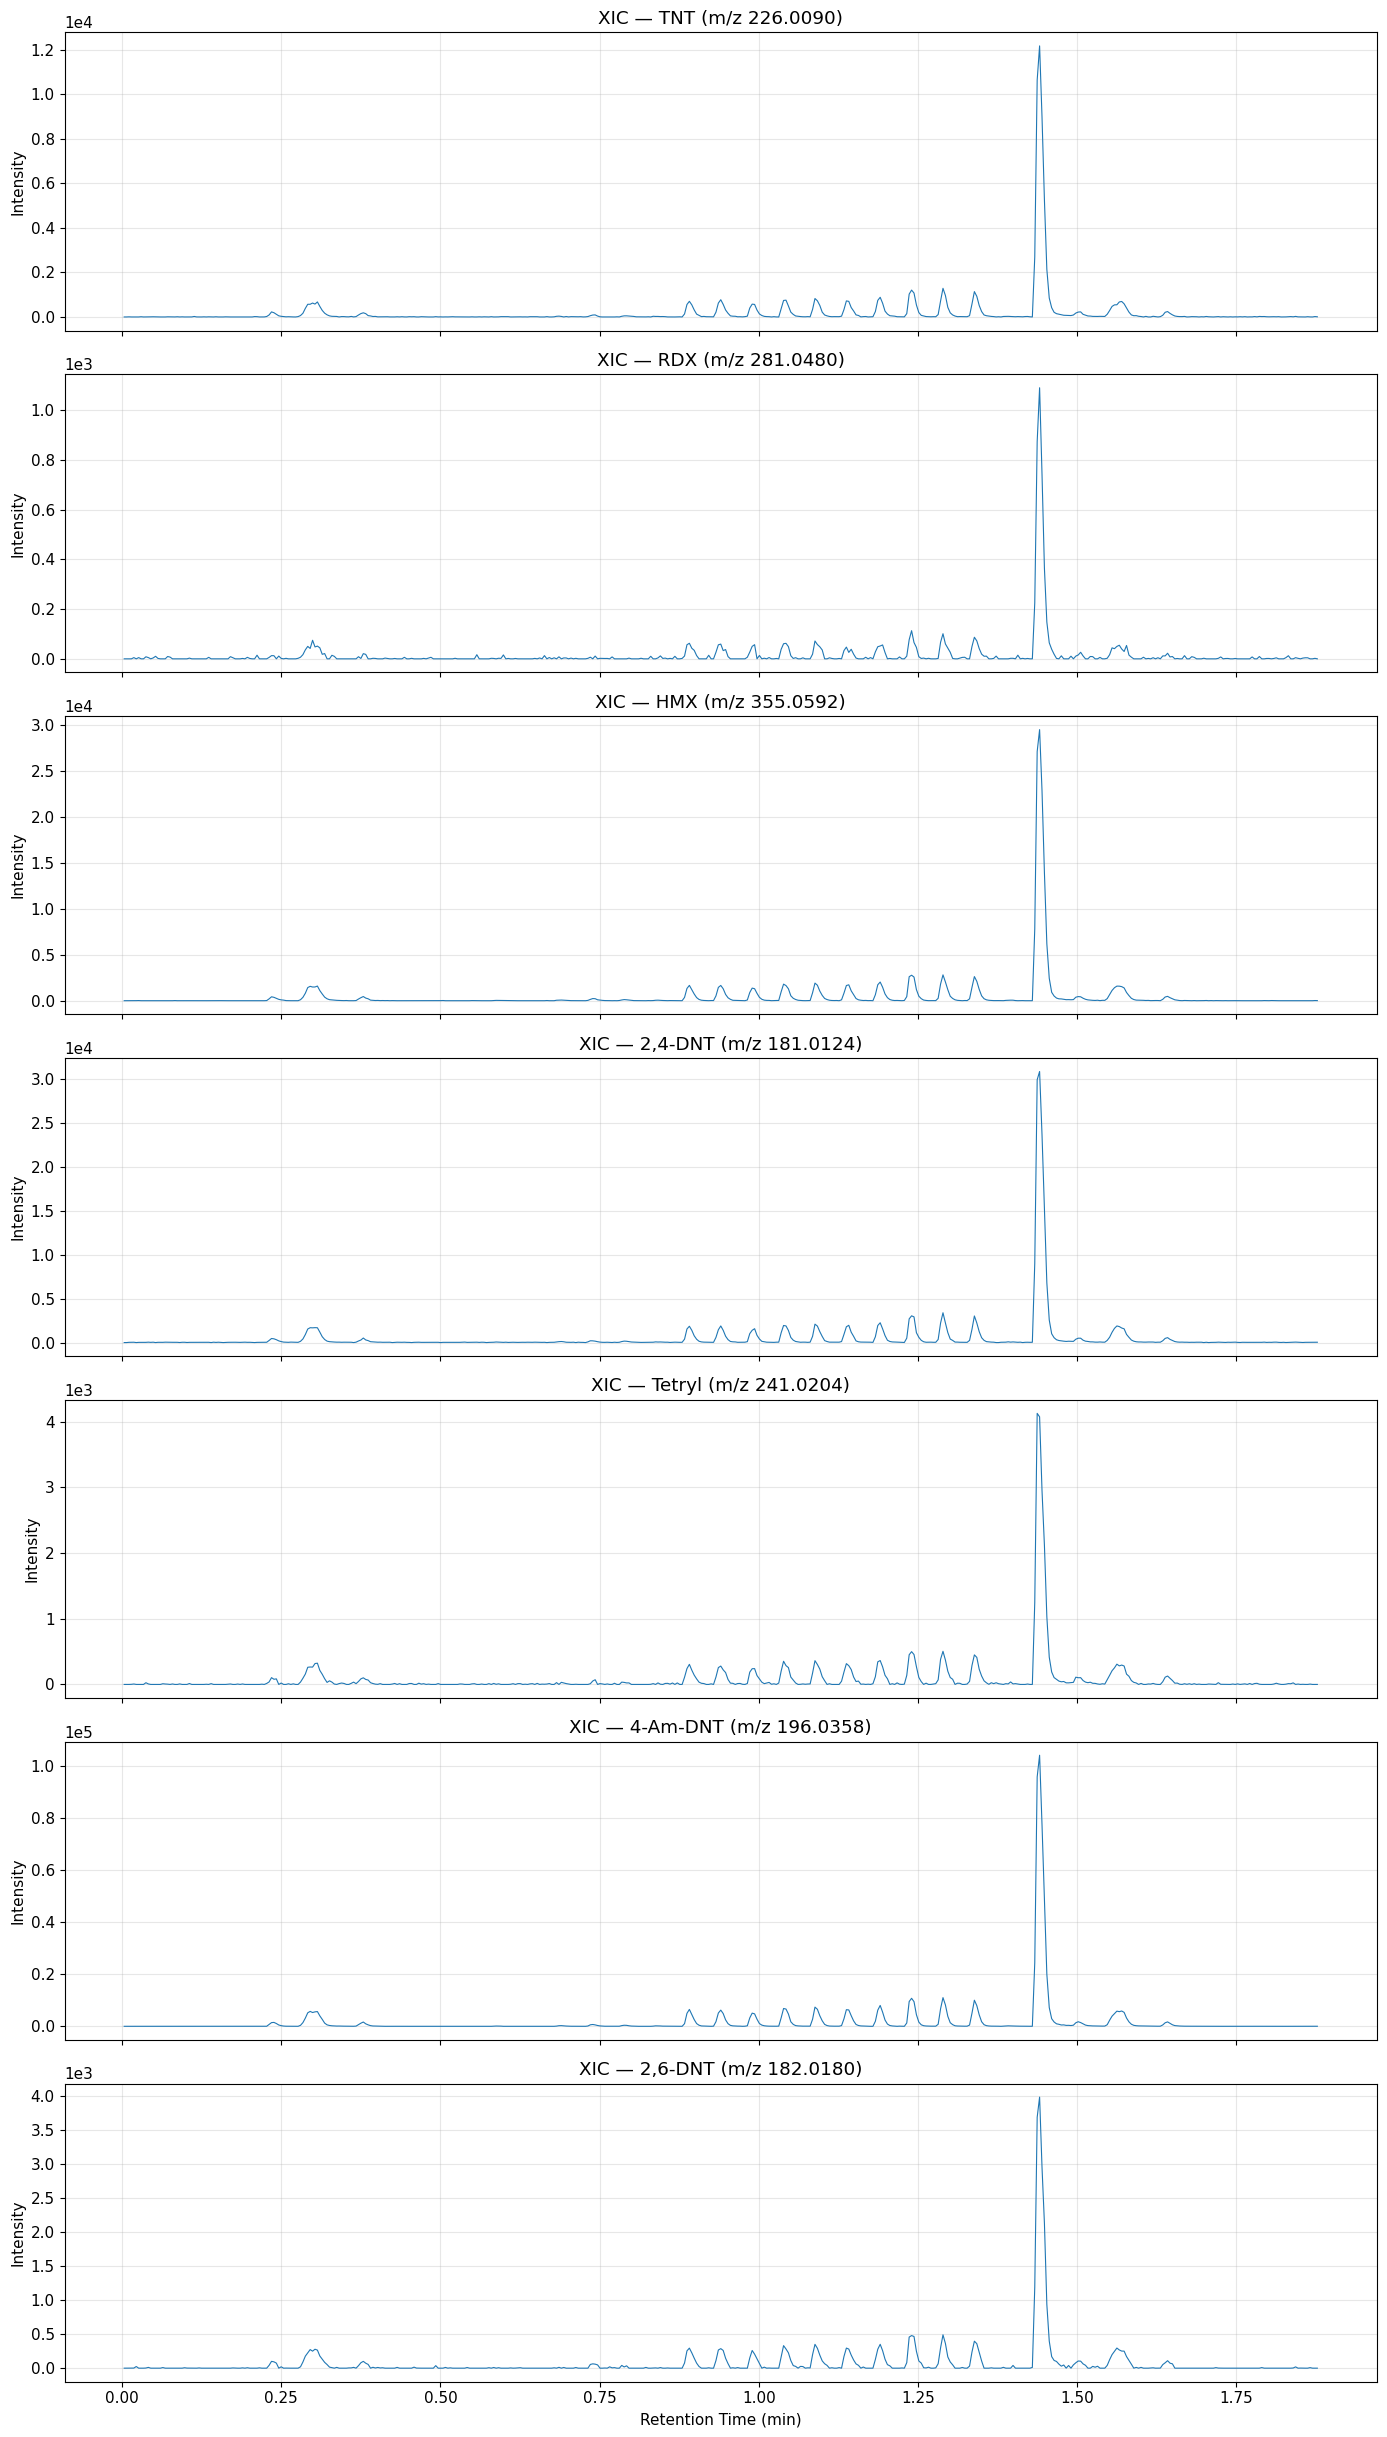

In [5]:
# XIC 시각화 — 검출된 화합물만
detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}

n_plots = len(detected)
if n_plots == 0:
    print('검출된 화합물이 없습니다. tolerance 또는 데이터를 확인하세요.')
else:
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.5 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]
    
    for ax, (name, data) in zip(axes, detected.items()):
        ax.plot(data['rt'], data['intensity'], linewidth=0.8)
        ax.set_ylabel('Intensity')
        ax.set_title(f'XIC — {name} (m/z {data["mz"]:.3f})')
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(alpha=0.3)
    
    axes[-1].set_xlabel('Retention Time (min)')
    plt.tight_layout()
    plt.show()

## XIC Overlay -- 전체 화합물 비교

모든 검출 화합물의 XIC를 하나의 그래프에 겹쳐 그립니다. 두 가지 표현 방식을 사용합니다:

- **Log scale (절대 강도)**: 화합물 간 강도 차이가 수십~수백 배이므로 log 스케일이 필수. 4-Am-DNT처럼 강한 신호와 RDX처럼 약한 신호를 동시에 확인할 수 있습니다.
- **Normalized (각 max = 100%)**: 절대 강도를 무시하고 **피크 모양(shape)**만 비교합니다. 모든 화합물의 spike가 같은 시점에 나타나면 같은 echo drop에서 동시 검출된 것입니다. RT가 다르면 별도의 drop이나 carry-over일 수 있습니다.

Overlay 플롯은 **multi-compound 동시 분석**의 품질을 한눈에 평가하는 핵심 도구입니다.

In [6]:
# XIC Overlay: log scale + normalized
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

for name, data in detected.items():
    ax1.plot(data['rt'], data['intensity'], linewidth=1.2, label=f"{name} (m/z {data['mz']:.1f})")
ax1.set_ylabel('Intensity')
ax1.set_yscale('log')
ax1.set_title('XIC Overlay - All Compounds (log scale)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(alpha=0.3)

for name, data in detected.items():
    norm = data['intensity'] / data['intensity'].max() * 100 if data['intensity'].max() > 0 else data['intensity']
    ax2.plot(data['rt'], norm, linewidth=1.2, label=name)
ax2.set_ylabel('Normalized Intensity (%)')
ax2.set_xlabel('Retention Time (min)')
ax2.set_title('XIC Overlay - Normalized (each max=100%)')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## XIC 선택성 확인: 실제 화합물 vs 없는 화합물

XIC의 가장 큰 장점은 **선택성(selectivity)**입니다. 시료에 실제로 존재하는 화합물과 존재하지 않는 화합물의 XIC를 비교하면 이를 명확히 확인할 수 있습니다.

- **실제 화합물 (TNT, m/z 226.009)**: 뚜렷한 spike 패턴 -> 시료에 존재하는 것이 확실
- **없는 화합물 (Caffeine, m/z 193.072)**: 노이즈만 보임 -> 시료에 없음
- 두 XIC의 **강도 비(signal ratio)**가 클수록 선택성이 좋은 것
- 실제 분석에서 이 방법으로 "진짜 검출 vs 위양성(false positive)"을 구분합니다
- 만약 없는 화합물의 XIC에도 spike가 보인다면, tolerance가 너무 넓거나 간섭 이온이 있는 것입니다

TNT      max intensity: 12170
Caffeine max intensity: 20
Signal ratio: 594x
-> Caffeine XIC = noise only (not in sample)


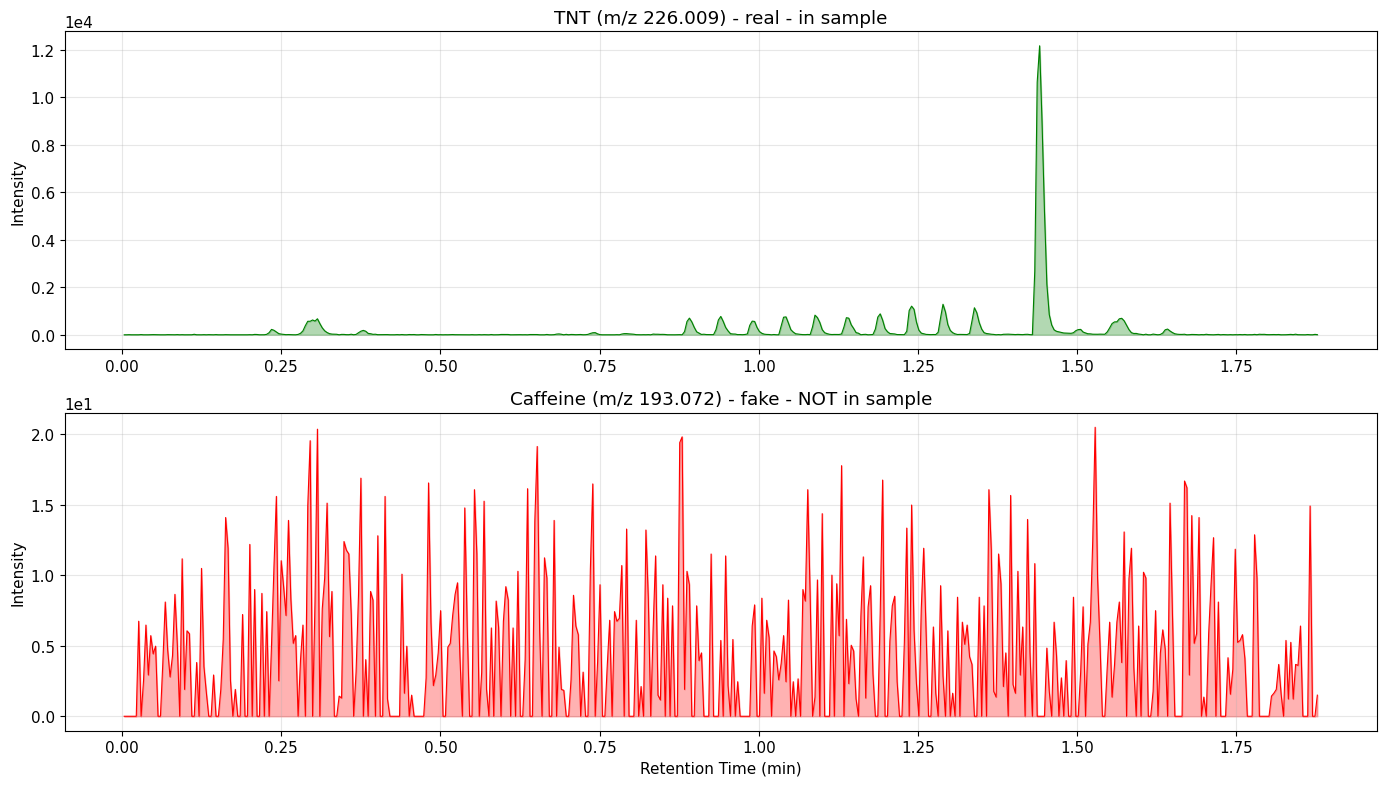

In [7]:
# 실제 화합물 vs 없는 화합물 XIC 비교
real_compound = {'name': 'TNT', 'mz': 226.009, 'note': 'real - in sample'}
absent_compound = {'name': 'Caffeine', 'mz': 193.072, 'note': 'absent - NOT in sample'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Real: TNT
rt_real, int_real = extract_xic(exp_tof, real_compound['mz'])
ax1.fill_between(rt_real, 0, int_real, alpha=0.3, color='green')
ax1.plot(rt_real, int_real, 'g-', linewidth=0.8)
ax1.set_title(f"{real_compound['name']} (m/z {real_compound['mz']:.3f}) - {real_compound['note']}")
ax1.set_ylabel('Intensity')
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax1.grid(alpha=0.3)

# Fake: Caffeine (not in explosives standard)
rt_absent, int_absent = extract_xic(exp_tof, absent_compound['mz'])
ax2.fill_between(rt_absent, 0, int_absent, alpha=0.3, color='red')
ax2.plot(rt_absent, int_absent, 'r-', linewidth=0.8)
ax2.set_title(f"{absent_compound['name']} (m/z {absent_compound['mz']:.3f}) - {absent_compound['note']}")
ax2.set_ylabel('Intensity')
ax2.set_xlabel('Retention Time (min)')
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax2.grid(alpha=0.3)

# Scale comparison
print(f"TNT      max intensity: {int_real.max():.0f}")
print(f"Caffeine max intensity: {int_absent.max():.0f}")
ratio = int_real.max() / int_absent.max() if int_absent.max() > 0 else float('inf')
print(f"Signal ratio: {ratio:.0f}x")
print(f"-> Caffeine XIC = noise only (not in sample)")

plt.tight_layout()
plt.show()

---

⬅️ **Prev:** [Mass Spectrum](02%20Mass%20Spectrum.ipynb) | **Next:** [MS/MS & Fragment](04%20MSMS%20Fragment.ipynb) ➡️